<a href="https://colab.research.google.com/github/r1manyadav/calculator/blob/main/loan_pred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [43]:
a=pd.read_excel('/content/bank-additional-full_final (3).xlsx')

In [44]:
a.shape

(41188, 20)

In [45]:
a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  poutcome        41188 non-null  object 
 14  emp.var.rate    41188 non-null  float64
 15  cons.price.idx  41188 non-null  float64
 16  cons.conf.idx   41188 non-null  float64
 17  euribor3m       41188 non-null 

In [46]:
a.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [47]:
a.drop_duplicates(inplace=True)

In [48]:
a

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [49]:
a.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous',
       'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [50]:
a.values

array([[56, 'housemaid', 'married', ..., 4.857, 5191.0, 'no'],
       [57, 'services', 'married', ..., 4.857, 5191.0, 'no'],
       [37, 'services', 'married', ..., 4.857, 5191.0, 'no'],
       ...,
       [56, 'retired', 'married', ..., 1.028, 4963.6, 'no'],
       [44, 'technician', 'married', ..., 1.028, 4963.6, 'yes'],
       [74, 'retired', 'married', ..., 1.028, 4963.6, 'no']], dtype=object)

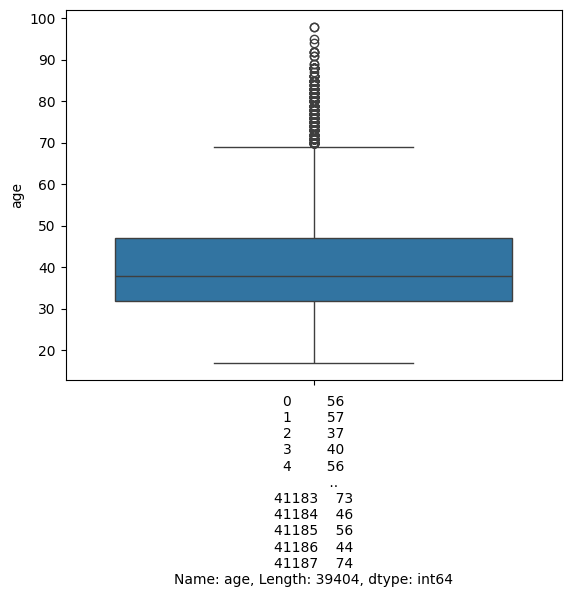

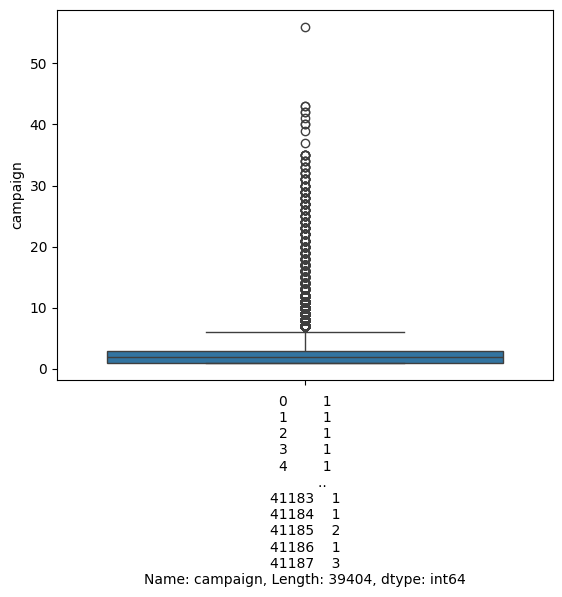

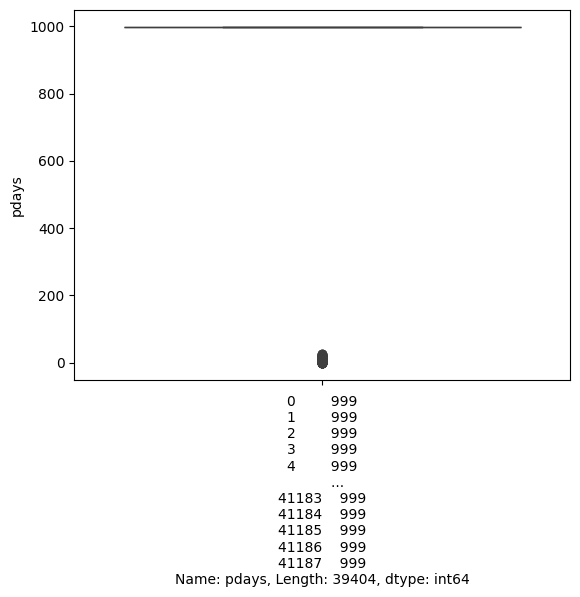

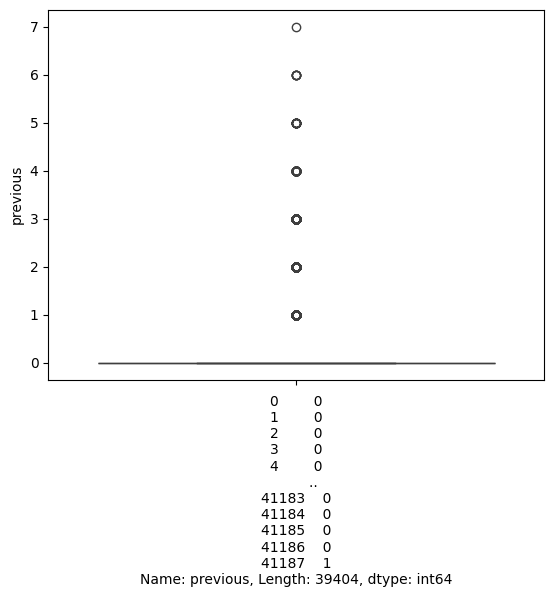

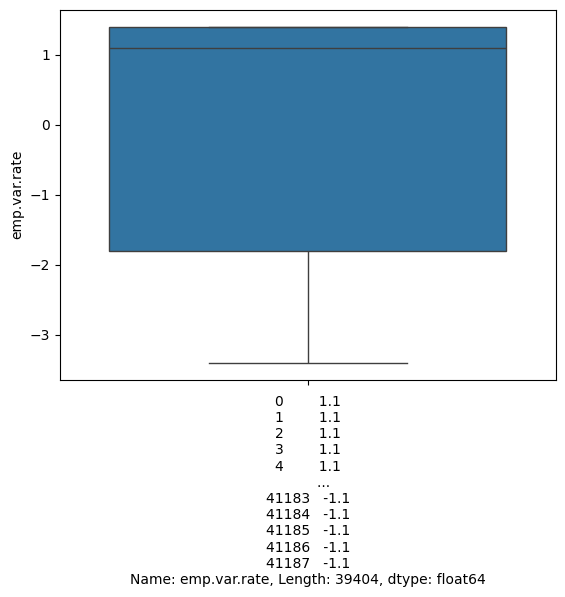

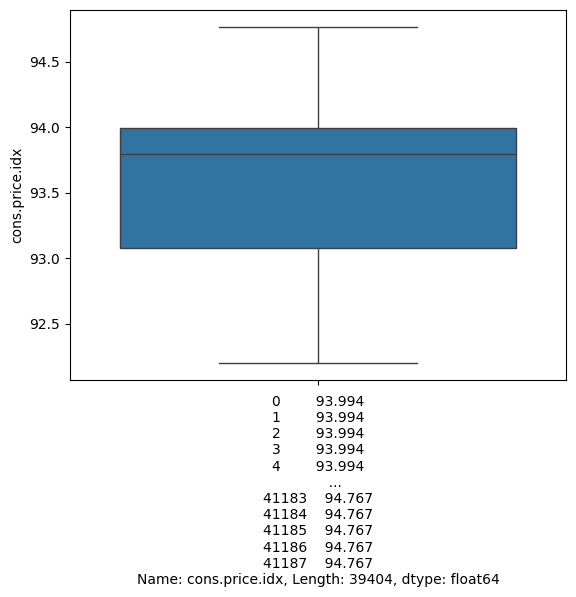

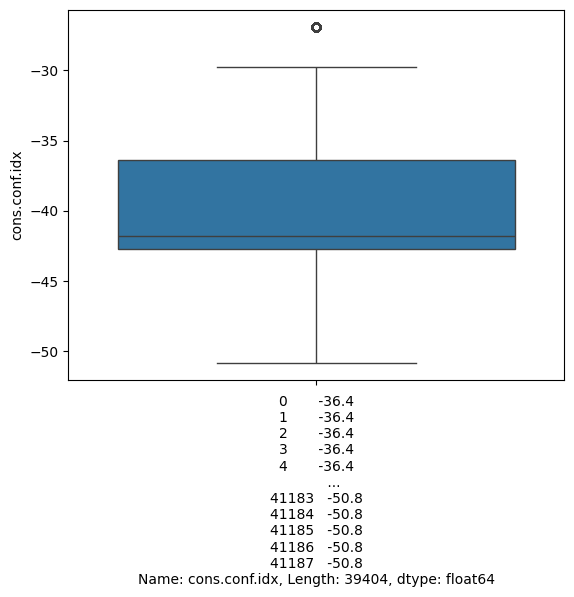

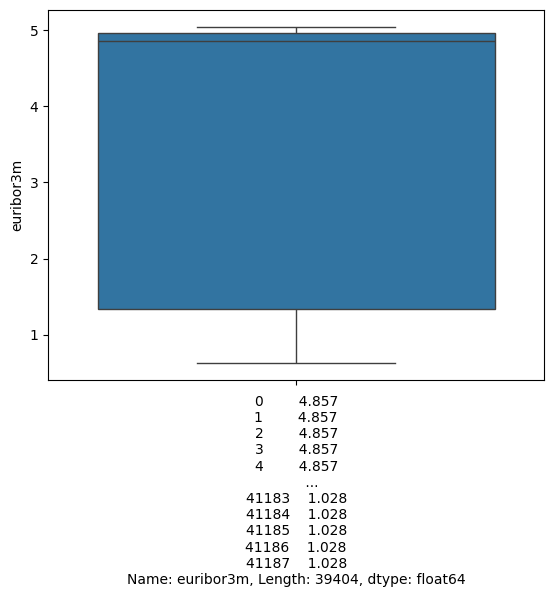

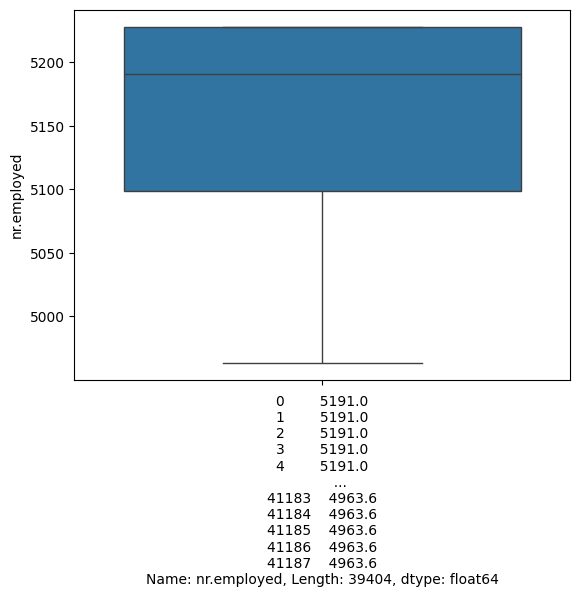

In [51]:
for col in a.columns:
  if(a[col].dtype!='object'):
    sns.boxplot(a[col])
    plt.xlabel(a[col])
    plt.show()

In [52]:
outliers = {}
for col in a.select_dtypes(include=np.number).columns:
    Q1 = a[col].quantile(0.25)
    Q3 = a[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    col_outliers = a[(a[col] < lower_bound) | (a[col] > upper_bound)]
    if not col_outliers.empty:
        outliers[col] = col_outliers

# Display the columns with outliers and the number of outliers in each
for col, data in outliers.items():
    print(f"Column '{col}' has {len(data)} outliers.")
    # Optionally display the outlier data
    # display(data)

Column 'age' has 458 outliers.
Column 'campaign' has 2398 outliers.
Column 'pdays' has 1514 outliers.
Column 'previous' has 5546 outliers.
Column 'cons.conf.idx' has 436 outliers.


In [53]:
# Remove outliers based on the bounds calculated in the previous cell
# Filter rows where values are within the calculated bounds for each column with outliers
for col, data in outliers.items():
    Q1 = a[col].quantile(0.25)
    Q3 = a[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    a = a[(a[col] >= lower_bound) & (a[col] <= upper_bound)]

print("Shape of the dataframe after removing outliers:", a.shape)

Shape of the dataframe after removing outliers: (31083, 20)


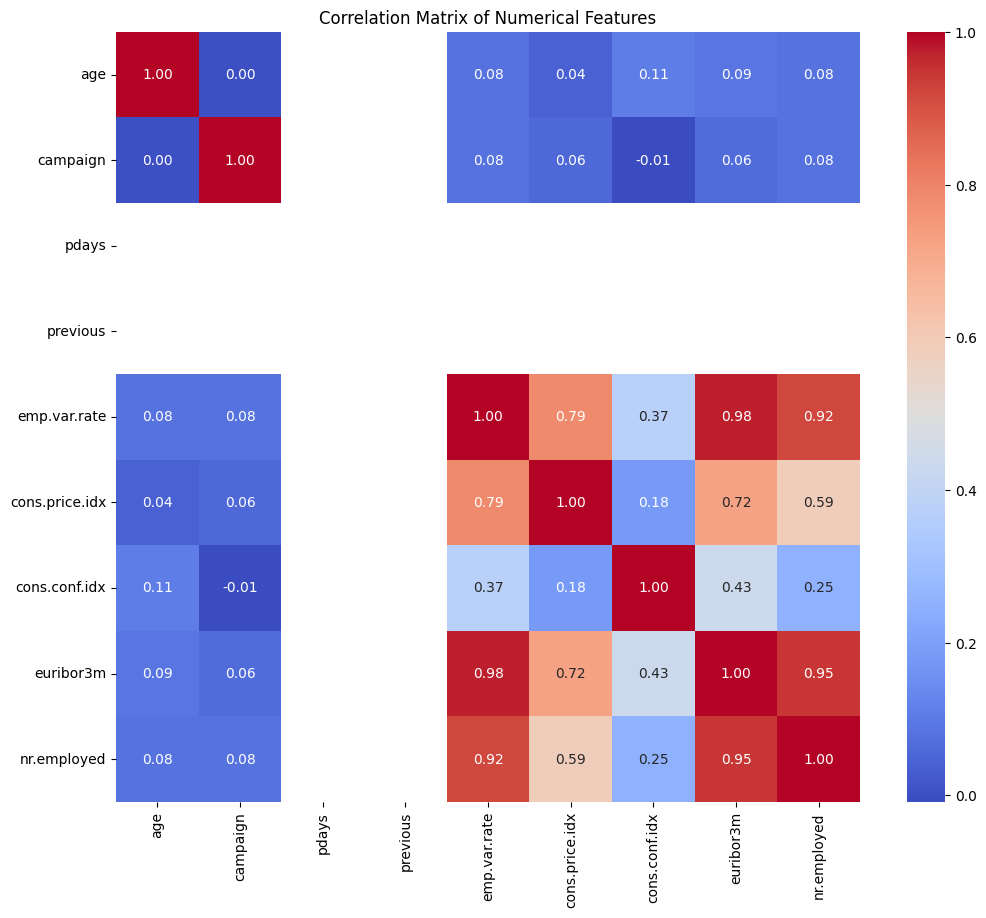

In [54]:
# Calculate the correlation matrix for numerical columns
correlation_matrix = a.select_dtypes(include=np.number).corr()

# Display the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [55]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Assuming X contains the features after one-hot encoding and before scaling
# We need to ensure X is a DataFrame and has numeric columns for VIF calculation

# Check if X exists and is a DataFrame, otherwise recreate it based on the current 'a'
if 'X' not in locals() or not isinstance(X, pd.DataFrame):
    # Recreate X from the current state of 'a', dropping the target variable and any non-numeric columns
    # Assuming 'y_encoded' is the target variable after the previous steps
    if 'y_encoded' in a.columns:
        X = a.drop(columns=[col for col in ['y', 'y_yes', 'y_encoded'] if col in a.columns])
    elif 'y_yes' in a.columns:
         X = a.drop(columns=[col for col in ['y', 'y_yes', 'y_encoded'] if col in a.columns])
    elif 'y' in a.columns and a['y'].dtype != 'object':
         X = a.drop(columns=[col for col in ['y', 'y_yes', 'y_encoded'] if col in a.columns])
    else:
         print("Could not identify a target column to exclude for VIF calculation.")
         # Attempt to use all numeric columns if no clear target is found
         X = a.select_dtypes(include=np.number)


# Ensure all columns in X are numeric for VIF calculation
X_numeric = X.select_dtypes(include=np.number)

if X_numeric.empty:
    print("No numeric features available for VIF calculation.")
else:
    # Calculate VIF for each feature
    vif_data = pd.DataFrame()
    vif_data["feature"] = X_numeric.columns
    vif_data["VIF"] = [variance_inflation_factor(X_numeric.values, i) for i in range(X_numeric.shape[1])]

    print("VIF before removing multicollinearity:")
    display(vif_data.sort_values(by="VIF", ascending=False))

    # Remove features with high VIF (e.g., VIF > 10)
    high_vif_features = vif_data[vif_data['VIF'] > 10]['feature'].tolist()
    if high_vif_features:
        X_reduced = X_numeric.drop(columns=high_vif_features)
        print(f"\nRemoved features with VIF > 10: {high_vif_features}")

        # Recalculate VIF for the reduced set of features
        vif_data_reduced = pd.DataFrame()
        vif_data_reduced["feature"] = X_reduced.columns
        vif_data_reduced["VIF"] = [variance_inflation_factor(X_reduced.values, i) for i in range(X_reduced.shape[1])]

        print("\nVIF after removing multicollinearity:")
        display(vif_data_reduced.sort_values(by="VIF", ascending=False))

        # Update X to the reduced set of features
        X = X_reduced
    else:
        print("\nNo features with VIF > 10 found. No features removed.")

VIF before removing multicollinearity:


,feature,VIF
3,cons.price.idx,122.298319
4,cons.conf.idx,93.904299
0,age,18.700571
1,campaign,3.615076
2,previous,NaN



Removed features with VIF > 10: ['age', 'cons.price.idx', 'cons.conf.idx']

VIF after removing multicollinearity:


,feature,VIF
0,campaign,1.0
1,previous,NaN


In [56]:
a.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31083 entries, 0 to 41186
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             31083 non-null  int64  
 1   job             31083 non-null  object 
 2   marital         31083 non-null  object 
 3   education       31083 non-null  object 
 4   default         31083 non-null  object 
 5   housing         31083 non-null  object 
 6   loan            31083 non-null  object 
 7   contact         31083 non-null  object 
 8   month           31083 non-null  object 
 9   day_of_week     31083 non-null  object 
 10  campaign        31083 non-null  int64  
 11  pdays           31083 non-null  int64  
 12  previous        31083 non-null  int64  
 13  poutcome        31083 non-null  object 
 14  emp.var.rate    31083 non-null  float64
 15  cons.price.idx  31083 non-null  float64
 16  cons.conf.idx   31083 non-null  float64
 17  euribor3m       31083 non-null  floa

In [57]:
# Use the reduced feature set after addressing multicollinearity (X_reduced)
# and the encoded target variable (y)

# Ensure y is correctly defined from the dataframe 'a'
if 'y_encoded' in a.columns:
    y = a['y_encoded']
elif 'y' in a.columns and a['y'].dtype != 'object':
     y = a['y']
else:
    print("Could not find a suitable target variable 'y_encoded' or numeric 'y'.")
    y = None

if y is not None:
    # Use the X_reduced from the multicollinearity step
    X = X_reduced

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print("Shape of X_train:", X_train.shape)
    print("Shape of X_test:", X_test.shape)
    print("Shape of y_train:", y_train.shape)
    print("Shape of y_test:", y_test.shape)
else:
    print("Skipping data splitting as target variable was not found.")

Could not find a suitable target variable 'y_encoded' or numeric 'y'.
Skipping data splitting as target variable was not found.


In [58]:
# Initialize and train the Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [59]:
from sklearn.metrics import accuracy_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate and print the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the Logistic Regression model: {accuracy:.4f}")

Accuracy of the Logistic Regression model: 0.9106
